# Part 3: Conv 레이어 채널 분해

## 이 노트북에서 다루는 내용
1. 채널 분해(Channel Decomposition) 원리
2. Conv2d 레이어에 다양한 rank 적용
3. Fine-tuning 후 정확도 회복
4. Combined: Linear SVD + Conv 분해 동시 적용
5. 분해 전/후 Feature Map 비교

## 채널 분해 원리

Conv2d(in_c, out_c, k×k)를 두 단계로 분해:

$$\text{Conv2d}(in\_c, out\_c, k) \rightarrow \text{Conv2d}(in\_c, rank, 1) + \text{Conv2d}(rank, out\_c, k)$$

1. **1×1 Pointwise Conv**: 입력 채널을 rank 차원으로 축소
2. **k×k Spatial Conv**: 축소된 채널에서 공간 필터링

### features.2 예시 (Conv2d(128, 64, 3×3))

| Rank | 파라미터 | 비율 |
|------|---------|------|
| 원본 | 73,728 | 100% |
| 32 | 22,528 | 30.6% |
| 16 | 11,264 | 15.3% |
| 8 | 5,632 | 7.6% |

## [1] 환경 설정 및 데이터 로드

In [1]:
import copy

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import (
    CNN,
    decompose_model_linear, decompose_model_conv,
    get_reconstruction_error
)

# 환경 설정
def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print(f"Using device: {DEVICE}")

# 하이퍼파라미터
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10

# Low-Rank 전용
FINETUNE_EPOCHS = 5
FINETUNE_LR = 0.0001
CONV_RANKS = [32, 16, 8]
COMBINED_LINEAR_RANK = 128
COMBINED_CONV_RANK = 32

SEED = 42
torch.manual_seed(SEED)

Using device: cuda


In [2]:
# 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"학습 데이터: {len(train_dataset):,} 샘플")
print(f"테스트 데이터: {len(test_dataset):,} 샘플")

학습 데이터: 50,000 샘플
테스트 데이터: 10,000 샘플


## [2] 학습 및 평가 함수

In [3]:
def train(model, train_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()

    epoch_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f"  Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

    return epoch_losses


def fine_tune(model, train_loader, epochs, learning_rate, device):
    return train(model, train_loader, epochs, learning_rate, device)


def test(model, test_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

## [3] Baseline 모델 준비

In [4]:
torch.manual_seed(SEED)
model = CNN(num_classes=NUM_CLASSES).to(DEVICE)

print("Baseline 모델 학습 중...")
train_losses = train(model, train_loader, EPOCHS, LEARNING_RATE, DEVICE)
baseline_acc = test(model, test_loader, DEVICE)
baseline_params = count_parameters(model)

print(f"\nBaseline 정확도: {baseline_acc:.2f}%")
print(f"Baseline 파라미터: {baseline_params:,}")

Baseline 모델 학습 중...
  Epoch 1/10, Loss: 1.3422
  Epoch 2/10, Loss: 0.8709
  Epoch 3/10, Loss: 0.6855
  Epoch 4/10, Loss: 0.5462
  Epoch 5/10, Loss: 0.4350
  Epoch 6/10, Loss: 0.3331
  Epoch 7/10, Loss: 0.2431
  Epoch 8/10, Loss: 0.1872
  Epoch 9/10, Loss: 0.1485
  Epoch 10/10, Loss: 0.1347

Baseline 정확도: 75.01%
Baseline 파라미터: 1,186,986


## [4] Conv 레이어 분석

In [5]:
print(f"{'Layer':<20} {'Shape':<25} {'Params':<12} {'비율':<8}")
print("-" * 65)

for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        W = module.weight.data
        num_params = W.numel() + (module.bias.numel() if module.bias is not None else 0)
        ratio = num_params / baseline_params * 100
        print(f"{name:<20} {str(list(W.shape)):<25} {num_params:>10,} {ratio:>6.1f}%")

print(f"\n→ features.2 (Conv2d(128, 64, 3, 3))가 Conv 중 가장 큰 레이어")

Layer                Shape                     Params       비율      
-----------------------------------------------------------------
features.0           [128, 3, 3, 3]                 3,584    0.3%
features.2           [64, 128, 3, 3]               73,792    6.2%
features.5           [64, 64, 3, 3]                36,928    3.1%
features.7           [32, 64, 3, 3]                18,464    1.6%

→ features.2 (Conv2d(128, 64, 3, 3))가 Conv 중 가장 큰 레이어


## [5] Conv 분해 실험 (다양한 rank)

In [6]:
print(f"대상: features.2 (Conv2d 128→64, 3×3)")
print(f"실험 ranks: {CONV_RANKS}")

conv_results = []

for rank in CONV_RANKS:
    print(f"\n--- Conv Rank = {rank} ---")

    decomposed_model = decompose_model_conv(model, {'features.2': rank})
    decomposed_params = count_parameters(decomposed_model)
    compression_ratio = baseline_params / decomposed_params

    acc_before_ft = test(decomposed_model, test_loader, DEVICE)
    print(f"분해 직후: {acc_before_ft:.2f}%")
    print(f"파라미터: {decomposed_params:,} ({decomposed_params/baseline_params*100:.1f}%)")

    print(f"Fine-tuning ({FINETUNE_EPOCHS} epochs)...")
    ft_losses = fine_tune(decomposed_model, train_loader, FINETUNE_EPOCHS, FINETUNE_LR, DEVICE)

    acc_after_ft = test(decomposed_model, test_loader, DEVICE)
    print(f"Fine-tuning 후: {acc_after_ft:.2f}%")

    original_weight = model.features[2].weight.data.cpu()
    out_c, in_c, k_h, k_w = original_weight.shape
    W_reshaped = original_weight.reshape(out_c * k_h * k_w, in_c)
    recon_error = get_reconstruction_error(W_reshaped, rank)

    conv_results.append({
        'rank': rank,
        'params': decomposed_params,
        'param_ratio': decomposed_params / baseline_params,
        'compression_ratio': compression_ratio,
        'acc_before_ft': acc_before_ft,
        'acc_after_ft': acc_after_ft,
        'ft_losses': ft_losses
    })

대상: features.2 (Conv2d 128→64, 3×3)
실험 ranks: [32, 16, 8]

--- Conv Rank = 32 ---
분해 직후: 10.74%
파라미터: 1,135,786 (95.7%)
Fine-tuning (5 epochs)...
  Epoch 1/5, Loss: 1.0548
  Epoch 2/5, Loss: 0.2907
  Epoch 3/5, Loss: 0.1633
  Epoch 4/5, Loss: 0.1078
  Epoch 5/5, Loss: 0.0774
Fine-tuning 후: 75.52%

--- Conv Rank = 16 ---
분해 직후: 12.74%
파라미터: 1,124,522 (94.7%)
Fine-tuning (5 epochs)...
  Epoch 1/5, Loss: 1.5350
  Epoch 2/5, Loss: 0.5723
  Epoch 3/5, Loss: 0.3001
  Epoch 4/5, Loss: 0.1945
  Epoch 5/5, Loss: 0.1351
Fine-tuning 후: 75.16%

--- Conv Rank = 8 ---
분해 직후: 11.91%
파라미터: 1,118,890 (94.3%)
Fine-tuning (5 epochs)...
  Epoch 1/5, Loss: 1.6012
  Epoch 2/5, Loss: 0.8800
  Epoch 3/5, Loss: 0.5179
  Epoch 4/5, Loss: 0.3370
  Epoch 5/5, Loss: 0.2394
Fine-tuning 후: 74.44%


In [7]:
# 결과 요약
print(f"{'Rank':<8} {'Before FT':<12} {'After FT':<12} {'Params':<12} {'압축률':<10}")
print("-" * 54)
for r in conv_results:
    print(f"{r['rank']:<8} {r['acc_before_ft']:<12.2f} {r['acc_after_ft']:<12.2f} "
          f"{r['params']:<12,} {r['compression_ratio']:<10.2f}x")

Rank     Before FT    After FT     Params       압축률       
------------------------------------------------------
32       10.74        75.52        1,135,786    1.05      x
16       12.74        75.16        1,124,522    1.06      x
8        11.91        74.44        1,118,890    1.06      x


## [6] Conv 분해 시각화

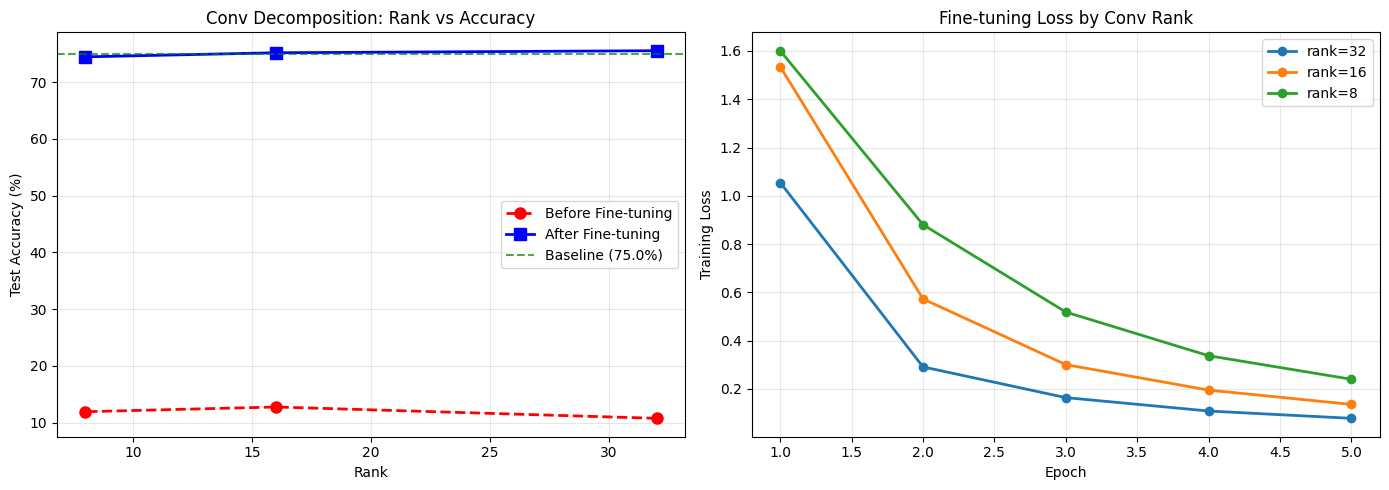

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ranks = [r['rank'] for r in conv_results]
accs_before = [r['acc_before_ft'] for r in conv_results]
accs_after = [r['acc_after_ft'] for r in conv_results]

# (1) Rank vs 정확도
ax1 = axes[0]
ax1.plot(ranks, accs_before, 'ro--', linewidth=2, markersize=8, label='Before Fine-tuning')
ax1.plot(ranks, accs_after, 'bs-', linewidth=2, markersize=8, label='After Fine-tuning')
ax1.axhline(y=baseline_acc, color='green', linestyle='--', alpha=0.7,
            label=f'Baseline ({baseline_acc:.1f}%)')
ax1.set_xlabel('Rank')
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Conv Decomposition: Rank vs Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# (2) Fine-tuning loss 곡선
ax2 = axes[1]
for r in conv_results:
    epochs = range(1, len(r['ft_losses']) + 1)
    ax2.plot(epochs, r['ft_losses'], linewidth=2, marker='o',
             label=f"rank={r['rank']}")
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Training Loss')
ax2.set_title('Fine-tuning Loss by Conv Rank')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## [7] Combined 분해 (Linear SVD + Conv)

In [9]:
print(f"Combined 분해: Linear(rank={COMBINED_LINEAR_RANK}) + Conv(rank={COMBINED_CONV_RANK})")

combined_model = decompose_model_linear(model, {'classifier.0': COMBINED_LINEAR_RANK})
combined_model = decompose_model_conv(combined_model, {'features.2': COMBINED_CONV_RANK})

combined_params = count_parameters(combined_model)
compression_ratio = baseline_params / combined_params

combined_acc_before = test(combined_model, test_loader, DEVICE)
print(f"분해 직후: {combined_acc_before:.2f}%")
print(f"파라미터: {combined_params:,} ({combined_params/baseline_params*100:.1f}%)")
print(f"압축률: {compression_ratio:.2f}x")

print(f"\nFine-tuning ({FINETUNE_EPOCHS} epochs)...")
combined_ft_losses = fine_tune(combined_model, train_loader, FINETUNE_EPOCHS, FINETUNE_LR, DEVICE)

combined_acc_after = test(combined_model, test_loader, DEVICE)
print(f"Fine-tuning 후: {combined_acc_after:.2f}%")

Combined 분해: Linear(rank=128) + Conv(rank=32)
분해 직후: 10.63%
파라미터: 414,890 (35.0%)
압축률: 2.86x

Fine-tuning (5 epochs)...
  Epoch 1/5, Loss: 1.1487
  Epoch 2/5, Loss: 0.4231
  Epoch 3/5, Loss: 0.2742
  Epoch 4/5, Loss: 0.1977
  Epoch 5/5, Loss: 0.1490
Fine-tuning 후: 75.66%


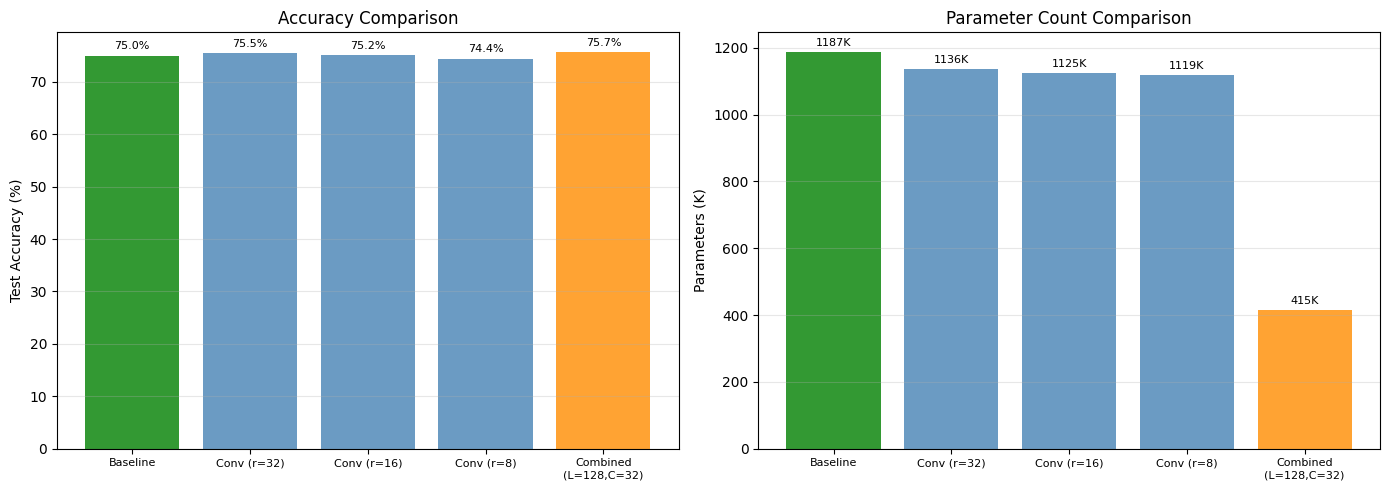

In [10]:
# Combined 종합 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

methods = ['Baseline']
accs = [baseline_acc]
params = [baseline_params]

for r in conv_results:
    methods.append(f'Conv (r={r["rank"]})')
    accs.append(r['acc_after_ft'])
    params.append(r['params'])

methods.append(f'Combined\n(L={COMBINED_LINEAR_RANK},C={COMBINED_CONV_RANK})')
accs.append(combined_acc_after)
params.append(combined_params)

x = np.arange(len(methods))
colors = ['green'] + ['steelblue'] * len(conv_results) + ['darkorange']

# 정확도
ax1 = axes[0]
bars = ax1.bar(x, accs, color=colors, alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(methods, fontsize=8)
ax1.set_ylabel('Test Accuracy (%)')
ax1.set_title('Accuracy Comparison')
ax1.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, accs):
    ax1.annotate(f'{acc:.1f}%',
                 xy=(bar.get_x() + bar.get_width() / 2, acc),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=8)

# 파라미터
ax2 = axes[1]
bars = ax2.bar(x, [p / 1000 for p in params], color=colors, alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(methods, fontsize=8)
ax2.set_ylabel('Parameters (K)')
ax2.set_title('Parameter Count Comparison')
ax2.grid(True, alpha=0.3, axis='y')
for bar, p in zip(bars, params):
    ax2.annotate(f'{p/1000:.0f}K',
                 xy=(bar.get_x() + bar.get_width() / 2, p / 1000),
                 xytext=(0, 3), textcoords="offset points",
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## [8] Feature Map 비교

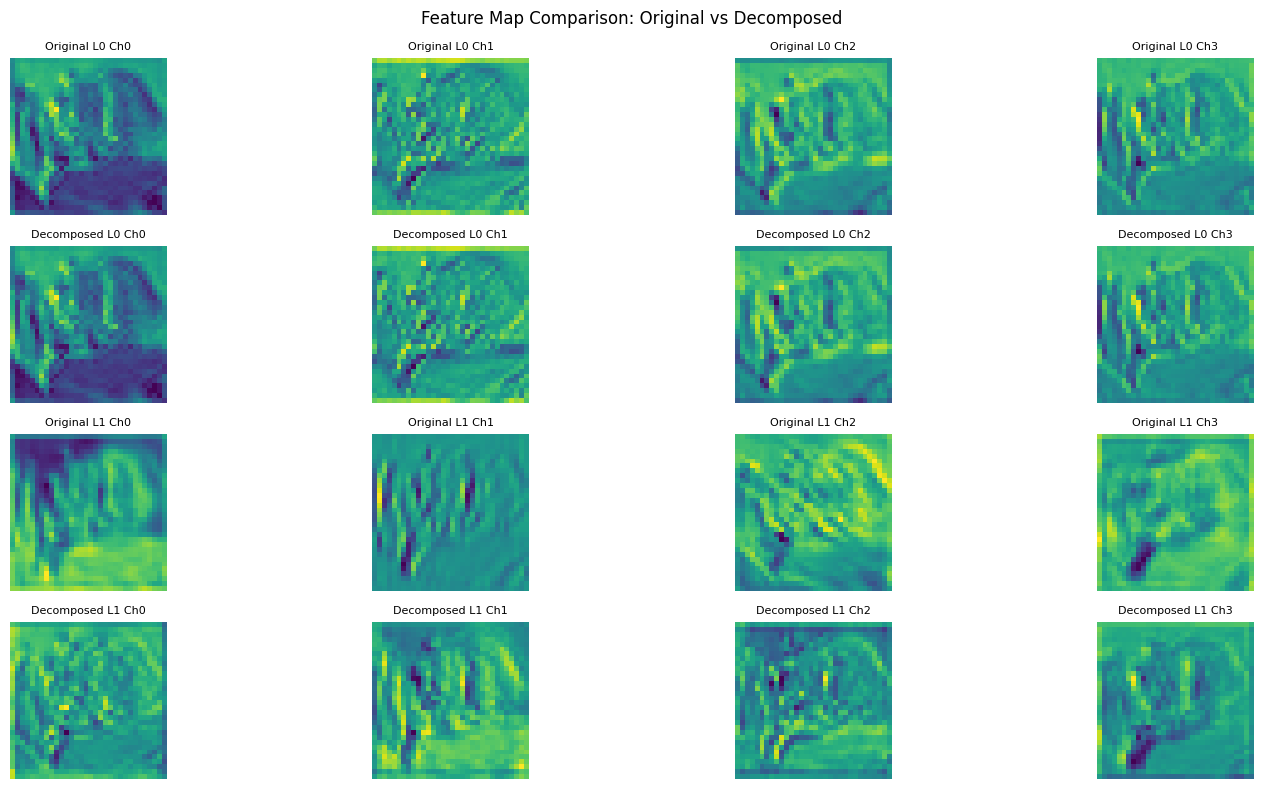

In [11]:
# 분해 모델 준비 (시각화용)
decomposed_for_viz = decompose_model_conv(model, {'features.2': 32})

# 테스트 이미지
images, labels = next(iter(test_loader))
image = images[0:1].to(DEVICE)

# Feature map 추출
def get_conv_outputs(model, x):
    model.to(DEVICE)
    model.eval()
    outputs = []
    with torch.no_grad():
        for layer in model.features:
            x = layer(x)
            if isinstance(layer, nn.Conv2d) or hasattr(layer, 'conv_pointwise'):
                outputs.append(x.cpu())
    return outputs

orig_outputs = get_conv_outputs(model, image)
decomp_outputs = get_conv_outputs(decomposed_for_viz, image)

# 첫 2개 Conv 출력의 처음 4채널 비교
n_compare = min(2, len(orig_outputs), len(decomp_outputs))
n_ch = 4

fig, axes = plt.subplots(n_compare * 2, n_ch, figsize=(16, 4 * n_compare))

for layer_idx in range(n_compare):
    for ch in range(n_ch):
        # 원본
        ax = axes[layer_idx * 2][ch]
        ax.imshow(orig_outputs[layer_idx][0, ch].numpy(), cmap='viridis')
        ax.set_title(f'Original L{layer_idx} Ch{ch}', fontsize=8)
        ax.axis('off')

        # 분해
        ax = axes[layer_idx * 2 + 1][ch]
        if ch < decomp_outputs[layer_idx].shape[1]:
            ax.imshow(decomp_outputs[layer_idx][0, ch].numpy(), cmap='viridis')
        ax.set_title(f'Decomposed L{layer_idx} Ch{ch}', fontsize=8)
        ax.axis('off')

fig.suptitle('Feature Map Comparison: Original vs Decomposed', fontsize=12)
plt.tight_layout()
plt.show()

## 결과 요약

In [12]:
print("=" * 60)
print("결과 요약")
print("=" * 60)
print(f"Baseline: {baseline_acc:.2f}% ({baseline_params:,} params)")
print()

print("Conv 분해 (features.2):")
for r in conv_results:
    print(f"  rank={r['rank']}: {r['acc_after_ft']:.2f}% ({r['compression_ratio']:.2f}x 압축)")

print()
print(f"Combined (Linear r={COMBINED_LINEAR_RANK} + Conv r={COMBINED_CONV_RANK}):")
print(f"  정확도: {combined_acc_after:.2f}%")
print(f"  파라미터: {combined_params:,} ({combined_params/baseline_params*100:.1f}%)")
print(f"  압축률: {compression_ratio:.2f}x")

print(f"\n핵심 관찰:")
print(f"  - Conv 분해는 Linear SVD보다 압축 효과가 작음")
print(f"    (Conv가 전체 파라미터의 ~11%만 차지)")
print(f"  - Linear SVD + Conv 분해를 결합하면 더 큰 압축 가능")
print(f"  - Fine-tuning으로 분해 후 정확도 회복 가능")
print(f"\n다음 단계: Part 4에서 종합 분석")

결과 요약
Baseline: 75.01% (1,186,986 params)

Conv 분해 (features.2):
  rank=32: 75.52% (1.05x 압축)
  rank=16: 75.16% (1.06x 압축)
  rank=8: 74.44% (1.06x 압축)

Combined (Linear r=128 + Conv r=32):
  정확도: 75.66%
  파라미터: 414,890 (35.0%)
  압축률: 2.86x

핵심 관찰:
  - Conv 분해는 Linear SVD보다 압축 효과가 작음
    (Conv가 전체 파라미터의 ~11%만 차지)
  - Linear SVD + Conv 분해를 결합하면 더 큰 압축 가능
  - Fine-tuning으로 분해 후 정확도 회복 가능

다음 단계: Part 4에서 종합 분석
